In [130]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import poisson

from datetime import datetime, timedelta, timezone
from tqdm import tqdm

import LowER
import LowER.background as bg
from LowER.sciencerun import SR1

# ER background spectrum

In [22]:
#load events
df_ER_b = pd.read_csv('low_ER_SR1b.csv')
df_ER_a = pd.read_csv('low_ER_SR1a.csv')

In [121]:
df_ER_a['energy'] = df_ER_a['ces']
df_ER_b['energy'] = df_ER_b['ces']

In [125]:
ER_events = np.shape(df_ER_a)[0] + np.shape(df_ER_b)[0]
ER_obs_days = 226.9 #https://journals.aps.org/prd/pdf/10.1103/PhysRevD.102.072004
print(ER_events)
print(ER_events/ER_obs_days)

42251
186.20978404583516


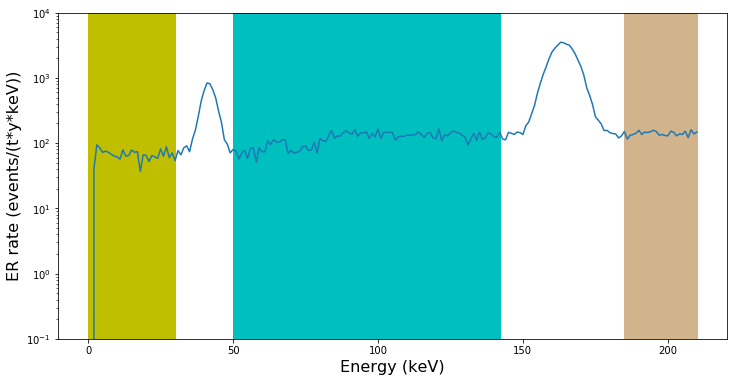

In [124]:
exposure = 0.65 #tonne-years

fig  = plt.figure(figsize=(12,6))
plt.xlabel('Energy (keV)', fontsize=16)
plt.ylabel('ER rate (events/(t*y*keV))', fontsize=16)
plt.axvspan(0, 30, color = 'y')
plt.axvspan(50, 142, color = 'c')
plt.axvspan(185, 210, color = 'tan')
rate_a = np.histogram(df_ER_a['energy'], bins=np.linspace(0,210,211))[0]/0.65 #(events/(t*y*keV))
rate_b = np.histogram(df_ER_b['energy'], bins=np.linspace(0,210,211))[0]/0.65 #(events/(t*y*keV))
rate = rate_a+rate_b
plt.plot(np.linspace(1,210,210), rate)
plt.yscale('log')
plt.ylim(0.1, 10000)
plt.show()

# Observed Rate

### Get information about datasets

In [13]:
sr1 = SR1()
runlist = sr1.runlist

coll = LowER.utils.runDB.get_collection()

query = {'number': {'$in': runlist}}

cursor = list(coll.find(query, {'start': 1, 'end': 1, 'number': 1, '_id': 0}))

dsets = pd.DataFrame(cursor)

dsets

,end,number,start
0,2018-02-07 01:53:39,16639,2018-02-07 00:53:35
1,2018-02-07 00:53:27,16638,2018-02-06 23:53:24
2,2018-02-06 23:53:16,16637,2018-02-06 22:53:13
3,2018-02-06 22:53:05,16636,2018-02-06 21:53:03
4,2018-02-06 21:52:55,16635,2018-02-06 20:52:52
5,2018-02-06 20:52:44,16634,2018-02-06 19:52:41
6,2018-02-06 19:52:33,16633,2018-02-06 18:52:30
7,2018-02-06 18:52:22,16632,2018-02-06 17:52:19
8,2018-02-06 17:52:11,16631,2018-02-06 16:52:08
9,2018-02-06 16:52:00,16630,2018-02-06 15:51:58


In [20]:
livetimes = []

for i in tqdm(range(0, np.shape(runlist)[0])):
    livetimes.append(LowER.utils.runDB.get_livetime_days([int(dsets.number[i]), ]))
    
dsets['livetime'] = livetimes #livetime is in days
dsets.head()

100%|██████████| 5873/5873 [01:44<00:00, 56.40it/s]


,end,number,start,livetime
0,2018-02-07 01:53:39,16639,2018-02-07 00:53:35,0.037964
1,2018-02-07 00:53:27,16638,2018-02-06 23:53:24,0.033586
2,2018-02-06 23:53:16,16637,2018-02-06 22:53:13,0.038051
3,2018-02-06 22:53:05,16636,2018-02-06 21:53:03,0.037993
4,2018-02-06 21:52:55,16635,2018-02-06 20:52:52,0.038093


In [23]:
#finding number of events for each run

events = []
for i in tqdm(range(0, np.shape(dsets)[0])):
    events.append(np.shape(df_ER_a[df_ER_a['run_number'] == dsets.number[i]])[0] + np.shape(df_ER_b[df_ER_b['run_number'] == dsets.number[i]])[0])
    
dsets['n_events'] = events

dsets.head()

100%|██████████| 5873/5873 [00:07<00:00, 820.54it/s]


,end,number,start,livetime,n_events
0,2018-02-07 01:53:39,16639,2018-02-07 00:53:35,0.037964,0
1,2018-02-07 00:53:27,16638,2018-02-06 23:53:24,0.033586,1
2,2018-02-06 23:53:16,16637,2018-02-06 22:53:13,0.038051,0
3,2018-02-06 22:53:05,16636,2018-02-06 21:53:03,0.037993,2
4,2018-02-06 21:52:55,16635,2018-02-06 20:52:52,0.038093,4


In [28]:
#finding number of events in different energy bins for each run 

ER_a_events_l = df_ER_a[(df_ER_a['energy']<=30)]
ER_a_events_peak1 = df_ER_a[(df_ER_a['energy']<50) & (df_ER_a['energy']>30)]
ER_a_events_m = df_ER_a[(df_ER_a['energy']<=142) & (df_ER_a['energy']>=50)]
ER_a_events_peak2 = df_ER_a[(df_ER_a['energy']>142) & (df_ER_a['energy']<185)]
ER_a_events_u = df_ER_a[(df_ER_a['energy']>=185)]

ER_b_events_l = df_ER_b[(df_ER_b['energy']<=30)]
ER_b_events_peak1 = df_ER_b[(df_ER_b['energy']<50) & (df_ER_b['energy']>30)]
ER_b_events_m = df_ER_b[(df_ER_b['energy']<=142) & (df_ER_b['energy']>=50)]
ER_b_events_peak2 = df_ER_b[(df_ER_b['energy']>142) & (df_ER_b['energy']<185)]
ER_b_events_u = df_ER_b[(df_ER_b['energy']>=185)]

events_l = []
events_m = []
events_u = []
events_peak1 = []
events_peak2 = []

for i in tqdm(range(0, np.shape(dsets)[0])):
    events_l.append(np.shape(ER_a_events_l[ER_a_events_l['run_number'] == dsets.number[i]])[0] + np.shape(ER_b_events_l[ER_b_events_l['run_number'] == dsets.number[i]])[0])
    events_m.append(np.shape(ER_a_events_m[ER_a_events_m['run_number'] == dsets.number[i]])[0] + np.shape(ER_b_events_m[ER_b_events_m['run_number'] == dsets.number[i]])[0])
    events_u.append(np.shape(ER_a_events_u[ER_a_events_u['run_number'] == dsets.number[i]])[0] + np.shape(ER_b_events_u[ER_b_events_u['run_number'] == dsets.number[i]])[0])
    events_peak1.append(np.shape(ER_a_events_peak1[ER_a_events_peak1['run_number'] == dsets.number[i]])[0] + np.shape(ER_b_events_peak1[ER_b_events_peak1['run_number'] == dsets.number[i]])[0])
    events_peak2.append(np.shape(ER_a_events_peak2[ER_a_events_peak2['run_number'] == dsets.number[i]])[0] + np.shape(ER_b_events_peak2[ER_b_events_peak2['run_number'] == dsets.number[i]])[0])

dsets['n_events_l'] = events_l
dsets['n_events_m'] = events_m
dsets['n_events_u'] = events_u
dsets['n_events_peak1'] = events_peak1
dsets['n_events_peak2'] = events_peak2
dsets.head()

100%|██████████| 5873/5873 [00:32<00:00, 178.30it/s]


,end,number,start,livetime,n_events,n_events_l,n_events_m,n_events_u,n_events_peak1,n_events_peak2
0,2018-02-07 01:53:39,16639,2018-02-07 00:53:35,0.037964,0,0,0,0,0,0
1,2018-02-07 00:53:27,16638,2018-02-06 23:53:24,0.033586,1,0,0,0,0,1
2,2018-02-06 23:53:16,16637,2018-02-06 22:53:13,0.038051,0,0,0,0,0,0
3,2018-02-06 22:53:05,16636,2018-02-06 21:53:03,0.037993,2,0,1,1,0,0
4,2018-02-06 21:52:55,16635,2018-02-06 20:52:52,0.038093,4,1,2,0,1,0


### Define days

In [9]:
dsets.start[np.shape(runlist)[0]-1]

Timestamp('2017-02-02 17:47:49')

In [10]:
first_date = datetime(2017, 2, 2)
first_date.timestamp()

1486015200.0

In [11]:
dsets.start[0]

Timestamp('2018-02-07 00:53:35')

In [12]:
last_date = datetime(2018, 2, 7)
last_date.timestamp()

1517983200.0

In [16]:
date_breaks = np.arange(first_date.timestamp(), last_date.timestamp()+24*3600, 24*3600)
datetime_breaks = []
for i in range(0, np.shape(date_breaks)[0]):
    datetime_breaks.append(datetime.fromtimestamp(date_breaks[i]))

## Rate of events

### Total - Across all energy

In [24]:
rate_event = []

for i in tqdm(range(0, np.shape(date_breaks)[0])):
    livetime = 0
    n_event = 0
    for j in (range(0, np.shape(runlist)[0])):
        if (dsets.start[j].timestamp() - date_breaks[i]) <= (24*3600) and (dsets.start[j].timestamp() - date_breaks[i]) >= 0:
            livetime = livetime + dsets.livetime[j]    
            n_event = n_event + dsets.n_events[j]
    if livetime == 0:
        rate_event.append(0)
    else:
        rate_event.append(n_event/livetime*365/1.042) #event-rate in events/(year*ton) 
        #1.042 is fiducial volume from lowER paper

100%|██████████| 371/371 [01:19<00:00,  3.40it/s]


/cvmfs/xenon.opensciencegrid.org/releases/anaconda/2.4/envs/lower/lib/python3.4/site-packages/matplotlib/axes/_axes.py:545: UserWarning: No labelled objects found. Use label='...' kwarg on individual plots.
  warnings.warn("No labelled objects found. "


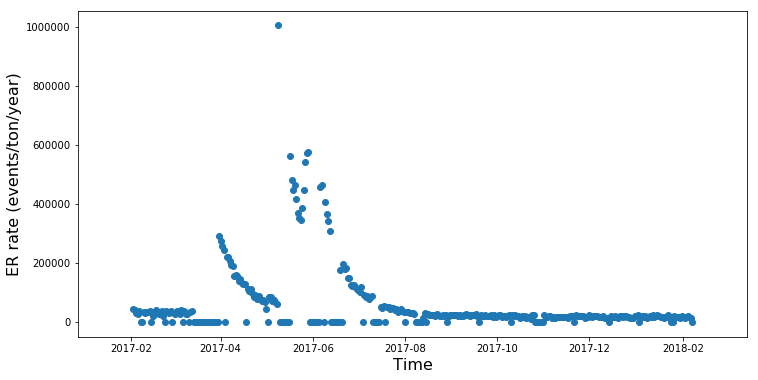

In [27]:
fig  = plt.figure(figsize=(12,6))
plt.xlabel('Time', fontsize=16)
plt.ylabel('ER rate (events/ton/year)', fontsize=16)
plt.scatter(datetime_breaks, rate_event)
plt.legend()
plt.show()

### Different energy bins

In [29]:
rate_event_l = []
rate_event_m = []
rate_event_u = []
rate_event_peak1 = []
rate_event_peak2 = []

for i in tqdm(range(0, np.shape(date_breaks)[0])):
    livetime = 0
    n_event_l = 0
    n_event_m = 0
    n_event_u = 0
    n_event_peak1 = 0
    n_event_peak2 = 0
    for j in (range(0, np.shape(runlist)[0])):
        if (dsets.start[j].timestamp() - date_breaks[i]) <= (24*3600) and (dsets.start[j].timestamp() - date_breaks[i]) >= 0:
            livetime = livetime + dsets.livetime[j]
            n_event_l = n_event_l + dsets.n_events_l[j]
            n_event_m = n_event_m + dsets.n_events_m[j]
            n_event_u = n_event_u + dsets.n_events_u[j]
            n_event_peak1 = n_event_peak1 + dsets.n_events_peak1[j]
            n_event_peak2 = n_event_peak2 + dsets.n_events_peak2[j]
    if livetime == 0:
        rate_event_l.append(0)
        rate_event_m.append(0)
        rate_event_u.append(0)
        rate_event_peak1.append(0)
        rate_event_peak2.append(0)
    else:
        rate_event_l.append(n_event_l/livetime*365/1.042)
        rate_event_m.append(n_event_m/livetime*365/1.042)
        rate_event_u.append(n_event_u/livetime*365/1.042)
        rate_event_peak1.append(n_event_peak1/livetime*365/1.042)
        rate_event_peak2.append(n_event_peak2/livetime*365/1.042)

100%|██████████| 371/371 [01:19<00:00,  3.37it/s]


/cvmfs/xenon.opensciencegrid.org/releases/anaconda/2.4/envs/lower/lib/python3.4/site-packages/matplotlib/axes/_axes.py:545: UserWarning: No labelled objects found. Use label='...' kwarg on individual plots.
  warnings.warn("No labelled objects found. "


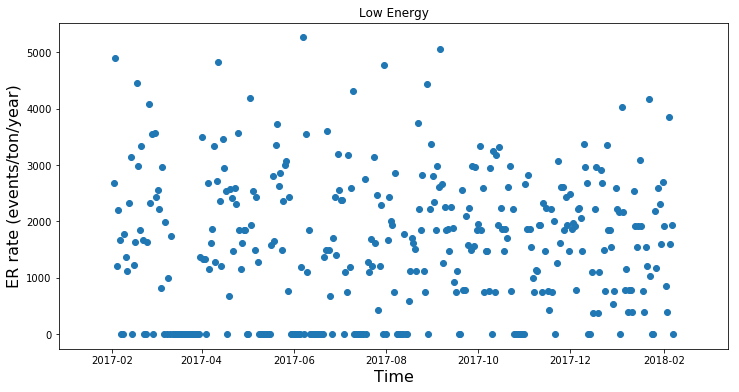

In [30]:
fig  = plt.figure(figsize=(12,6))
plt.xlabel('Time', fontsize=16)
plt.ylabel('ER rate (events/ton/year)', fontsize=16)
plt.scatter(datetime_breaks, rate_event_l)
plt.title("Low Energy")
plt.legend()
plt.show()

/cvmfs/xenon.opensciencegrid.org/releases/anaconda/2.4/envs/lower/lib/python3.4/site-packages/matplotlib/axes/_axes.py:545: UserWarning: No labelled objects found. Use label='...' kwarg on individual plots.
  warnings.warn("No labelled objects found. "


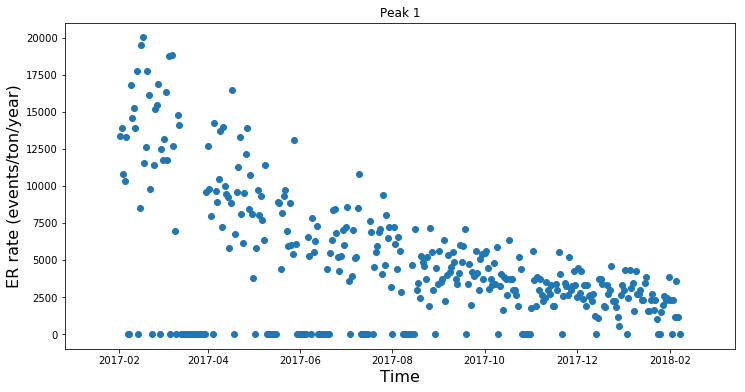

In [31]:
fig  = plt.figure(figsize=(12,6))
plt.xlabel('Time', fontsize=16)
plt.ylabel('ER rate (events/ton/year)', fontsize=16)
plt.scatter(datetime_breaks, rate_event_peak1)
plt.title("Peak 1")
plt.legend()
plt.show()

/cvmfs/xenon.opensciencegrid.org/releases/anaconda/2.4/envs/lower/lib/python3.4/site-packages/matplotlib/axes/_axes.py:545: UserWarning: No labelled objects found. Use label='...' kwarg on individual plots.
  warnings.warn("No labelled objects found. "


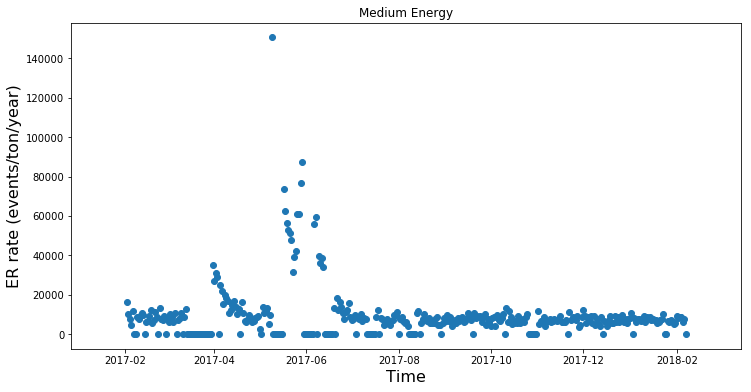

In [32]:
fig  = plt.figure(figsize=(12,6))
plt.xlabel('Time', fontsize=16)
plt.ylabel('ER rate (events/ton/year)', fontsize=16)
plt.scatter(datetime_breaks, rate_event_m)
plt.title("Medium Energy")
plt.legend()
plt.show()

/cvmfs/xenon.opensciencegrid.org/releases/anaconda/2.4/envs/lower/lib/python3.4/site-packages/matplotlib/axes/_axes.py:545: UserWarning: No labelled objects found. Use label='...' kwarg on individual plots.
  warnings.warn("No labelled objects found. "


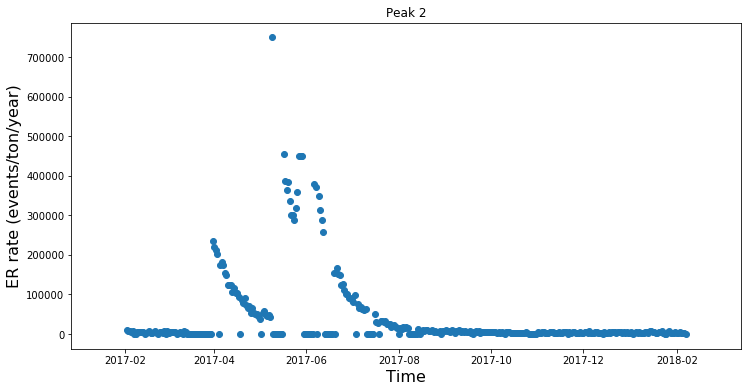

In [33]:
fig  = plt.figure(figsize=(12,6))
plt.xlabel('Time', fontsize=16)
plt.ylabel('ER rate (events/ton/year)', fontsize=16)
plt.scatter(datetime_breaks, rate_event_peak2)
plt.title("Peak 2")
plt.legend()
plt.show()

/cvmfs/xenon.opensciencegrid.org/releases/anaconda/2.4/envs/lower/lib/python3.4/site-packages/matplotlib/axes/_axes.py:545: UserWarning: No labelled objects found. Use label='...' kwarg on individual plots.
  warnings.warn("No labelled objects found. "


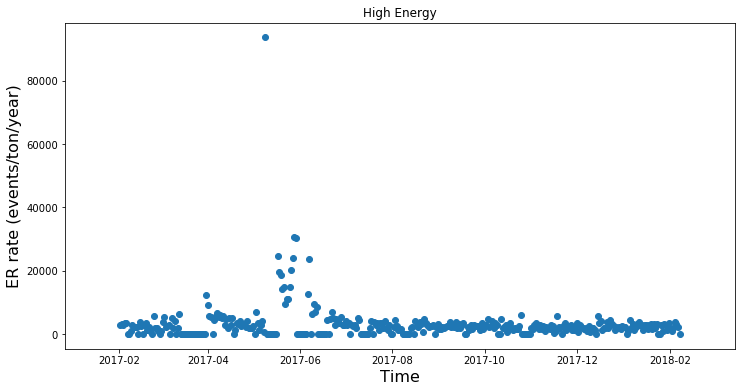

In [34]:
fig  = plt.figure(figsize=(12,6))
plt.xlabel('Time', fontsize=16)
plt.ylabel('ER rate (events/ton/year)', fontsize=16)
plt.scatter(datetime_breaks, rate_event_u)
plt.title("High Energy")
plt.legend()
plt.show()

# Background Model

In [83]:
# intialise data of lists.
GW = ['GW170729', 'GW170817', 'GW170818', 'GW170823']

GW_8_23_datetime = datetime(2017, 8, 23, 13, 13, 58, tzinfo=timezone.utc)
GW_8_18_datetime = datetime(2017, 8, 18, 2, 25, 9, tzinfo=timezone.utc)
GW_8_17_datetime = datetime(2017, 8, 17, 12, 41, 4, tzinfo=timezone.utc)
GW_7_29_datetime = datetime(2017, 7, 29, 18, 56, 29, tzinfo=timezone.utc)

GW_7_29_time = GW_7_29_datetime.timestamp()
GW_8_17_time = GW_8_17_datetime.timestamp()
GW_8_18_time = GW_8_18_datetime.timestamp()
GW_8_23_time = GW_8_23_datetime.timestamp()

data = {'Event': GW,
        'Event_time': [GW_7_29_time, GW_8_17_time, GW_8_18_time, GW_8_23_time],
        'Event_date': [GW_7_29_datetime, GW_8_17_datetime, GW_8_18_datetime, GW_8_23_datetime]
        }
Data = pd.DataFrame(data)
Data

,Event,Event_date,Event_time,n_ER
0,GW170729,2017-07-29 18:56:29+00:00,1.501355e+09,0
1,GW170817,2017-08-17 12:41:04+00:00,1.502974e+09,0
2,GW170818,2017-08-18 02:25:09+00:00,1.503023e+09,0
3,GW170823,2017-08-23 13:13:58+00:00,1.503494e+09,0


### Finding livetime

In [85]:
Data['start_time'] = ''
Data['end_time'] = ''

for j in range(0, np.shape(Data['Event_time'])[0]):
    Data['start_time'][j] = []
    Data['end_time'][j] = []
    for i in range(0, np.size(dsets.start)):
        delay_s = Data['Event_time'][j] - dsets.start[i].replace(tzinfo=timezone.utc).timestamp()
        if delay_s > 500 and delay_s<10500:
            Data['start_time'][j].append(dsets.start[i].replace(tzinfo=timezone.utc).timestamp())

        delay_e = Data['Event_time'][j] - dsets.end[i].replace(tzinfo=timezone.utc).timestamp()
        if delay_e > 500 and delay_e<10500:
            Data['end_time'][j].append(dsets.end[i].replace(tzinfo=timezone.utc).timestamp())

Data

/cvmfs/xenon.opensciencegrid.org/releases/anaconda/2.4/envs/lower/lib/python3.4/site-packages/ipykernel/__main__.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
/cvmfs/xenon.opensciencegrid.org/releases/anaconda/2.4/envs/lower/lib/python3.4/site-packages/ipykernel/__main__.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


,Event,Event_date,Event_time,n_ER,start_time,end_time
0,GW170729,2017-07-29 18:56:29+00:00,1.501355e+09,12,"[1501352317.0, 1501348706.0, 1501345098.0]","[1501352310.0, 1501348699.0, 1501345084.0]"
1,GW170817,2017-08-17 12:41:04+00:00,1.502974e+09,9,"[1502971682.0, 1502968071.0, 1502964462.0]","[1502971675.0, 1502968064.0, 1502964455.0]"
2,GW170818,2017-08-18 02:25:09+00:00,1.503023e+09,7,"[1503022261.0, 1503018651.0, 1503015039.0]","[1503022254.0, 1503018643.0, 1503015032.0]"
3,GW170823,2017-08-23 13:13:58+00:00,1.503494e+09,6,"[1503492385.0, 1503488774.0, 1503485164.0]","[1503492378.0, 1503488767.0, 1503485157.0]"


In [86]:
Data['missing_time'] = 0
for j in range(0, np.shape(Data['Event_time'])[0]):
    for i in range(0, 3):
        Data['missing_time'][j] = Data['missing_time'][j] + Data['start_time'][j][i] - Data['end_time'][j][i]
Data['livetime'] = 10000 - Data['missing_time']
Data

/cvmfs/xenon.opensciencegrid.org/releases/anaconda/2.4/envs/lower/lib/python3.4/site-packages/ipykernel/__main__.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


,Event,Event_date,Event_time,n_ER,start_time,end_time,missing_time,livetime
0,GW170729,2017-07-29 18:56:29+00:00,1.501355e+09,12,"[1501352317.0, 1501348706.0, 1501345098.0]","[1501352310.0, 1501348699.0, 1501345084.0]",28,9972
1,GW170817,2017-08-17 12:41:04+00:00,1.502974e+09,9,"[1502971682.0, 1502968071.0, 1502964462.0]","[1502971675.0, 1502968064.0, 1502964455.0]",21,9979
2,GW170818,2017-08-18 02:25:09+00:00,1.503023e+09,7,"[1503022261.0, 1503018651.0, 1503015039.0]","[1503022254.0, 1503018643.0, 1503015032.0]",22,9978
3,GW170823,2017-08-23 13:13:58+00:00,1.503494e+09,6,"[1503492385.0, 1503488774.0, 1503485164.0]","[1503492378.0, 1503488767.0, 1503485157.0]",21,9979


### Total - Across all energy

In [90]:
days = np.linspace(0, 365, 366)
t0 = datetime(2017, 2, 4, 3, 52, 14, 293773)
dates = t0 + np.array([timedelta(days=d) for d in days])
timestamp = np.array([dt.timestamp() for dt in dates])

Xe136 = bg.Xe136Model(runlist)
I125 = bg.I125Model(runlist)
solar_v = bg.SolarnuBackground(runlist)
material = bg.MaterialsBackground(runlist)
Pb214 =bg.Pb214Background(runlist)
Kr85 = bg.Kr85Background(runlist)
Xe124 = bg.DECBackground(runlist)

signal = bg.Kr83mSourceClosed.kr83m_rate(days) + Xe136.calculate_rate() + bg.Xe131mModel.decay_func(timestamp) + bg.Xe133Model.decay_func(timestamp) + I125.I125_rate(days) + solar_v.calculate_rate() + material.calculate_rate() + Pb214.calculate_rate() + Kr85.calculate_rate() + Xe124.expected_rate 

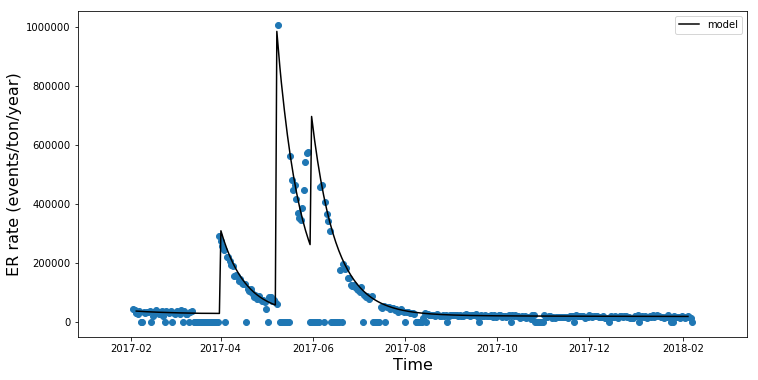

In [52]:
fig  = plt.figure(figsize=(12,6))
plt.xlabel('Time', fontsize=16)
plt.ylabel('ER rate (events/ton/year)', fontsize=16)
plt.scatter(datetime_breaks, rate_event)
plt.plot(dates, signal, label = 'model', color='black')
plt.legend()
plt.show()

In [91]:
#Expectation value for sideband time region

Data['Expected ER events (/year)'] = ''
for j in range(0,4):
    for i in (range(0, np.shape(dates)[0])):
        if (Data['Event_date'][j].year == dates[i].year and Data['Event_date'][j].month == dates[i].month and Data['Event_date'][j].day == dates[i].day):
            Data['Expected ER events (/year)'][j] = signal[i]
            
Data['Expected bkgd ER events'] = Data['Expected ER events (/year)']*Data['livetime']/(365*60*60*24)

/cvmfs/xenon.opensciencegrid.org/releases/anaconda/2.4/envs/lower/lib/python3.4/site-packages/ipykernel/__main__.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


In [53]:
#Copied this function from LowER.background because I need to use function calculate_rate()

from LowER import THISDIR, analysis_range, full_path
import pickle

class SolarnuBackground(bg.BackgroundModel):
    def calculate_rate(self, E_min = min(analysis_range), E_max = max(analysis_range)):
        """rate in analysis range, (1, 210) keV by default, in unit evts/t/year"""
        su = pickle.load(open(full_path('data/models/solarnu.pkl'), 'rb'))
        roi_mask = (su.bin_centers < E_max) & (su.bin_centers > E_min)
        rate = (su.bin_volumes()[roi_mask] * su.histogram[roi_mask]).sum()

        return rate

    def rate_uncertainty(self):
        """Gives the fractional rate uncertainty for this background"""
        # nt mc paper
        return 0.03


In [186]:
#Table 1 of lowER paper
rel_error_Pb = 160/7480
rel_error_Kr = 80/773
rel_error_materials = 0
rel_error_Xe136 = 120/2150
rel_error_solar = 4.7/220.8
rel_error_Xe133 = 85/4009
rel_error_Xe131m = 150/24270
rel_error_I125_K = 12/67
rel_error_I125_L = 2.3/13.1
rel_error_I125_M = 0.5/2.94
rel_error_Kr83m = 53/2671
rel_error_Xe124_KK = 24/113
rel_error_Xe124_KL = 7.3/34
rel_error_Xe124_LL = 0.55/2.56

### Low Energy

In [187]:
Pb214 =bg.Pb214Background(runlist)
Kr85 = bg.Kr85Background(runlist)
material = bg.MaterialsBackground(runlist)
solar_v = SolarnuBackground(runlist)
Xe124 = bg.DECBackground(runlist)

Xe133 = bg.Xe133Model(runlist)
Xe133_r = bg.Xe133Model(runlist, energy_range=(0, 30))
Xe136 = bg.Xe136Model(runlist, energy_range=(0, 30))

kk_br = 0.7554
kl_br = 0.2275
ll_br = 0.0171

signal = Pb214.calculate_rate() * 30/210 + Kr85.calculate_rate() * 30/210 + material.calculate_rate() * 30/210 + solar_v.calculate_rate(0, 30) + bg.Xe133Model.decay_func(timestamp) * Xe133_r.calculate_rate() / Xe133.calculate_rate() + Xe136.calculate_rate() + Xe124.expected_rate * ll_br / kk_br 
uncertainty = Pb214.calculate_rate() * 30/210 * rel_error_Pb + Kr85.calculate_rate() * 30/210 * rel_error_Kr + solar_v.calculate_rate(0, 30) * rel_error_solar + bg.Xe133Model.decay_func(timestamp) * Xe133_r.calculate_rate() / Xe133.calculate_rate() * rel_error_Xe133 + Xe136.calculate_rate() * rel_error_Xe136 + Xe124.expected_rate * ll_br / kk_br * rel_error_Xe124_LL 


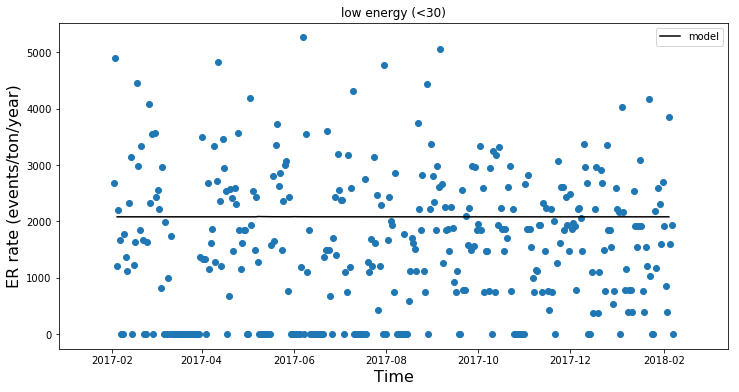

In [57]:
fig  = plt.figure(figsize=(12,6))
plt.title("low energy (<30)")
plt.xlabel('Time', fontsize=16)
plt.ylabel('ER rate (events/ton/year)', fontsize=16)
plt.scatter(datetime_breaks, rate_event_l)
plt.plot(dates, signal, label = 'model', color='black')

plt.legend()
plt.show()

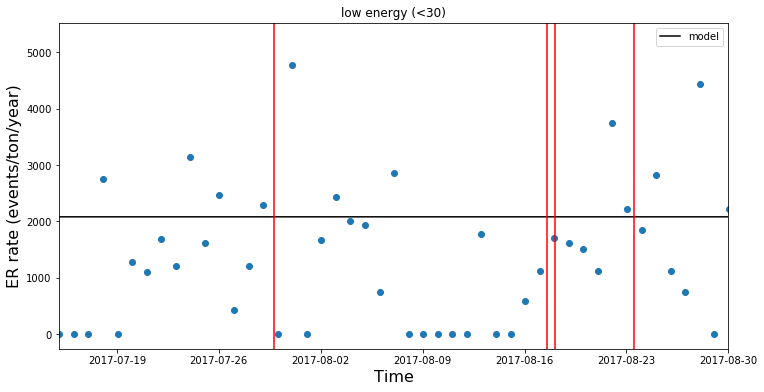

In [63]:
fig  = plt.figure(figsize=(12,6))
plt.title("low energy (<30)")
plt.xlabel('Time', fontsize=16)
plt.ylabel('ER rate (events/ton/year)', fontsize=16)
plt.scatter(datetime_breaks, rate_event_l)
plt.plot(dates, signal, label = 'model', color='black')

plt.axvline(GW_8_23_datetime, color='red')
plt.axvline(GW_8_18_datetime, color='red')
plt.axvline(GW_8_17_datetime, color='red')
plt.axvline(GW_7_29_datetime, color='red')
plt.xlim(datetime(2017, 7, 15), datetime(2017, 8, 30))

plt.legend()
plt.show()

In [188]:
#Expectation value for sideband time region

Data['Expected ER events (low) (/year)'] = ''
Data['systematic uncertainty (low) (/year)'] = ''

for j in range(0,4):
    for i in (range(0, np.shape(dates)[0])):
        if (Data['Event_date'][j].year == dates[i].year and Data['Event_date'][j].month == dates[i].month and Data['Event_date'][j].day == dates[i].day):
            Data['Expected ER events (low) (/year)'][j] = signal[i]
            Data['systematic uncertainty (low) (/year)'][j] = uncertainty[i]
            
Data['Expected bkgd ER events (low)'] = Data['Expected ER events (low) (/year)']*Data['livetime']/(365*60*60*24)
Data['systematic uncertainty (low)'] = Data['systematic uncertainty (low) (/year)']*1000/(365*60*60*24)

/cvmfs/xenon.opensciencegrid.org/releases/anaconda/2.4/envs/lower/lib/python3.4/site-packages/ipykernel/__main__.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
/cvmfs/xenon.opensciencegrid.org/releases/anaconda/2.4/envs/lower/lib/python3.4/site-packages/ipykernel/__main__.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


### Peak 1

In [190]:
Pb214 =bg.Pb214Background(runlist)
Kr85 = bg.Kr85Background(runlist)
material = bg.MaterialsBackground(runlist)
solar_v = SolarnuBackground(runlist)
I125 = bg.I125Model(runlist)
Xe124 = bg.DECBackground(runlist)

Xe136 = bg.Xe136Model(runlist, energy_range=(30, 50))
Xe133 = bg.Xe133Model(runlist)
Xe133_r = bg.Xe133Model(runlist, energy_range=(30, 50))

kshell_prob = 0.801
lshell_prob = 0.156

signal = bg.Kr83mSourceClosed.kr83m_rate(days) + Pb214.calculate_rate() * (50-30)/210 + Kr85.calculate_rate() * (50-30)/210 + material.calculate_rate() * (50-30)/210 + solar_v.calculate_rate(30, 50) + I125.I125_rate(days)*I125.lshell_prob + bg.Xe133Model.decay_func(timestamp) * Xe133_r.calculate_rate() / Xe133.calculate_rate() + Xe136.calculate_rate() + Xe124.expected_rate * kl_br / kk_br 
uncertainty = bg.Kr83mSourceClosed.kr83m_rate(days) * rel_error_Kr83m + Pb214.calculate_rate() * (50-30)/210 * rel_error_Pb + Kr85.calculate_rate() * (50-30)/210 * rel_error_Kr + solar_v.calculate_rate(30, 50) * rel_error_solar + I125.I125_rate(days)*I125.lshell_prob*rel_error_I125_L + bg.Xe133Model.decay_func(timestamp) * Xe133_r.calculate_rate() / Xe133.calculate_rate() * rel_error_Xe133 + Xe136.calculate_rate() * rel_error_Xe136 + rel_error_Xe124_KL * Xe124.expected_rate * kl_br / kk_br 

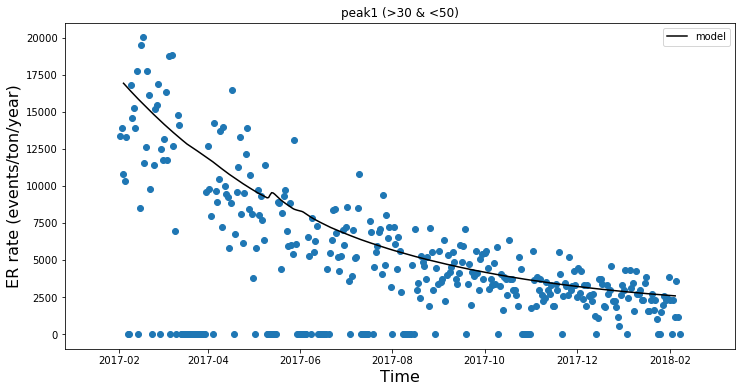

In [68]:
fig  = plt.figure(figsize=(12,6))
plt.title("peak1 (>30 & <50)")
plt.xlabel('Time', fontsize=16)
plt.ylabel('ER rate (events/ton/year)', fontsize=16)
plt.scatter(datetime_breaks, rate_event_peak1)
plt.plot(dates, signal, label = 'model', color='black')

plt.legend()
plt.show()

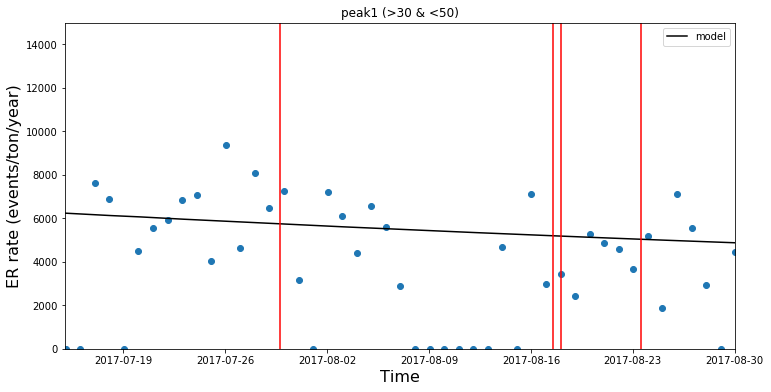

In [69]:
fig  = plt.figure(figsize=(12,6))
plt.title("peak1 (>30 & <50)")
plt.xlabel('Time', fontsize=16)
plt.ylabel('ER rate (events/ton/year)', fontsize=16)
plt.scatter(datetime_breaks, rate_event_peak1)

plt.plot(dates, signal, label = 'model', color='black')

plt.ylim(0, 15000)
plt.xlim(datetime(2017, 7, 15), datetime(2017, 8, 30))

plt.axvline(GW_8_23_datetime, color='red')
plt.axvline(GW_8_18_datetime, color='red')
plt.axvline(GW_8_17_datetime, color='red')
plt.axvline(GW_7_29_datetime, color='red')

plt.legend()
plt.show()

In [191]:
#Expectation value for sideband time region

Data['Expected ER events (peak1) (/year)'] = ''
Data['systematic uncertainty (peak1) (/year)'] = ''

for j in range(0,4):
    for i in (range(0, np.shape(dates)[0])):
        if (Data['Event_date'][j].year == dates[i].year and Data['Event_date'][j].month == dates[i].month and Data['Event_date'][j].day == dates[i].day):
            Data['Expected ER events (peak1) (/year)'][j] = signal[i]
            Data['systematic uncertainty (peak1) (/year)'][j] = uncertainty[i]

Data['Expected bkgd ER events (peak1)'] = Data['Expected ER events (peak1) (/year)']*Data['livetime']/(365*60*60*24)
Data['systematic uncertainty (peak1)'] = Data['systematic uncertainty (peak1) (/year)']*1000/(365*60*60*24)

/cvmfs/xenon.opensciencegrid.org/releases/anaconda/2.4/envs/lower/lib/python3.4/site-packages/ipykernel/__main__.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
/cvmfs/xenon.opensciencegrid.org/releases/anaconda/2.4/envs/lower/lib/python3.4/site-packages/ipykernel/__main__.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


### Medium Energy

In [193]:
Xe133 = bg.Xe133Model(runlist)
Xe133_r = bg.Xe133Model(runlist, energy_range=(50, 142))
Xe136 = bg.Xe136Model(runlist, energy_range=(50, 142))

I125 = bg.I125Model(runlist)
solar_v = SolarnuBackground(runlist)
material = bg.MaterialsBackground(runlist)
Kr85 = bg.Kr85Background(runlist)
Pb214 =bg.Pb214Background(runlist)
Xe124 = bg.DECBackground(runlist)

signal = bg.Xe133Model.decay_func(timestamp) * Xe133_r.calculate_rate() / Xe133.calculate_rate() + Xe136.calculate_rate() + I125.I125_rate(days)*I125.kshell_prob + solar_v.calculate_rate(50, 142) + material.calculate_rate() * (142-50)/210 + Kr85.calculate_rate() * (142-50)/210 + Pb214.calculate_rate() * (142-50)/210 + Xe124.expected_rate
uncertainty = bg.Xe133Model.decay_func(timestamp) * Xe133_r.calculate_rate() / Xe133.calculate_rate() * rel_error_Xe133 + Xe136.calculate_rate() * rel_error_Xe136 + I125.I125_rate(days)*I125.kshell_prob * rel_error_I125_K + solar_v.calculate_rate(50, 142) * rel_error_solar + Kr85.calculate_rate() * (142-50)/210 * rel_error_Kr + Pb214.calculate_rate() * (142-50)/210 * rel_error_Pb + rel_error_Xe124_KK * Xe124.expected_rate


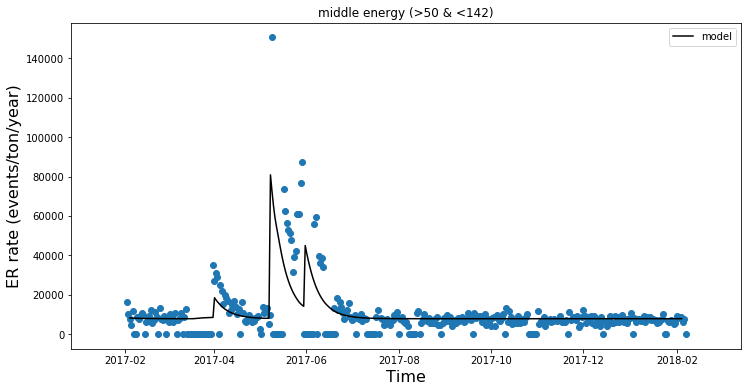

In [71]:
fig  = plt.figure(figsize=(12,6))
plt.title("middle energy (>50 & <142)")
plt.xlabel('Time', fontsize=16)
plt.ylabel('ER rate (events/ton/year)', fontsize=16)
plt.scatter(datetime_breaks, rate_event_m)

plt.plot(dates, signal, label = 'model', color='black')

plt.legend()
plt.show()

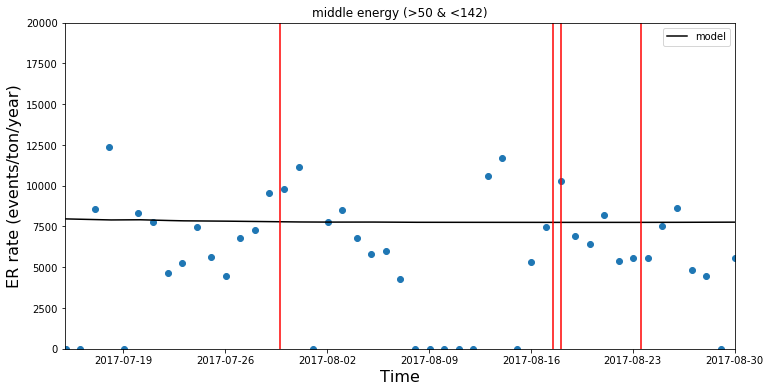

In [72]:
fig  = plt.figure(figsize=(12,6))
plt.title("middle energy (>50 & <142)")
plt.xlabel('Time', fontsize=16)
plt.ylabel('ER rate (events/ton/year)', fontsize=16)
plt.scatter(datetime_breaks, rate_event_m)

plt.plot(dates, signal, label = 'model', color='black')

plt.ylim(0, 20000)
plt.xlim(datetime(2017, 7, 15), datetime(2017, 8, 30))

plt.axvline(GW_8_23_datetime, color='red')
plt.axvline(GW_8_18_datetime, color='red')
plt.axvline(GW_8_17_datetime, color='red')
plt.axvline(GW_7_29_datetime, color='red')

plt.legend()
plt.show()

In [194]:
#Expectation value for sideband time region

Data['Expected ER events (medium) (/year)'] = ''
Data['systematic uncertainty (medium) (/year)'] = ''

for j in range(0,4):
    for i in (range(0, np.shape(dates)[0])):
        if (Data['Event_date'][j].year == dates[i].year and Data['Event_date'][j].month == dates[i].month and Data['Event_date'][j].day == dates[i].day):
            Data['Expected ER events (medium) (/year)'][j] = signal[i]
            Data['systematic uncertainty (medium) (/year)'][j] = uncertainty[i]
            
Data['Expected bkgd ER events (medium)'] = Data['Expected ER events (medium) (/year)']*Data['livetime']/(365*60*60*24)
Data['systematic uncertainty (medium)'] = Data['systematic uncertainty (medium) (/year)']*1000/(365*60*60*24)

/cvmfs/xenon.opensciencegrid.org/releases/anaconda/2.4/envs/lower/lib/python3.4/site-packages/ipykernel/__main__.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
/cvmfs/xenon.opensciencegrid.org/releases/anaconda/2.4/envs/lower/lib/python3.4/site-packages/ipykernel/__main__.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


### Peak 2

In [195]:
Xe133 = bg.Xe133Model(runlist)
Xe133_r = bg.Xe133Model(runlist, energy_range=(142, 185))
Xe136 = bg.Xe136Model(runlist, energy_range=(142, 185))

solar_v = SolarnuBackground(runlist)
material = bg.MaterialsBackground(runlist)
Kr85 = bg.Kr85Background(runlist)
Pb214 =bg.Pb214Background(runlist)

signal = bg.Xe131mModel.decay_func(timestamp) + bg.Xe133Model.decay_func(timestamp) * Xe133_r.calculate_rate() / Xe133.calculate_rate() + Xe136.calculate_rate() + solar_v.calculate_rate(142, 185) + material.calculate_rate() * (185-142)/210 + Kr85.calculate_rate() * (185-142)/210 + Pb214.calculate_rate() * (185-142)/210
uncertainty = bg.Xe131mModel.decay_func(timestamp) * rel_error_Xe131m + rel_error_Xe133 * bg.Xe133Model.decay_func(timestamp) * Xe133_r.calculate_rate() / Xe133.calculate_rate() + rel_error_Xe136 * Xe136.calculate_rate() + rel_error_solar * solar_v.calculate_rate(142, 185) + rel_error_Kr * Kr85.calculate_rate() * (185-142)/210 + rel_error_Pb * Pb214.calculate_rate() * (185-142)/210

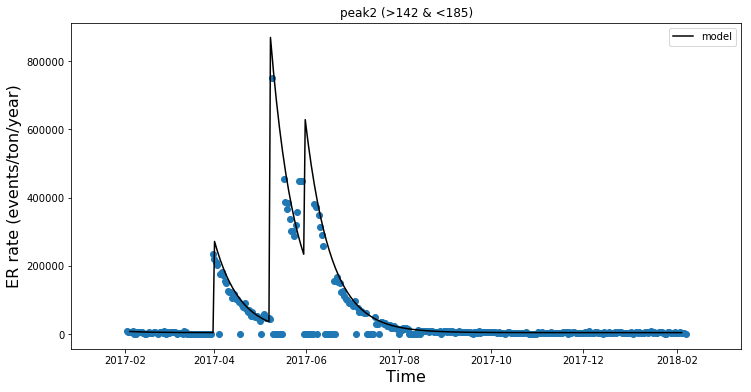

In [74]:
fig  = plt.figure(figsize=(12,6))
plt.title("peak2 (>142 & <185)")
plt.xlabel('Time', fontsize=16)
plt.ylabel('ER rate (events/ton/year)', fontsize=16)
plt.scatter(datetime_breaks, rate_event_peak2)

plt.plot(dates, signal, label = 'model', color='black')

plt.legend()
plt.show()

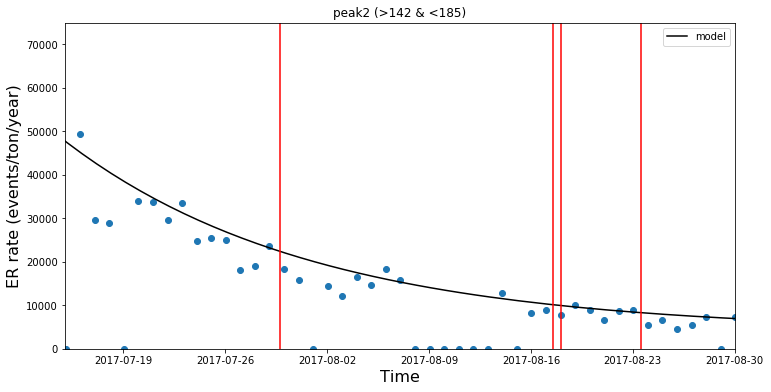

In [77]:
fig  = plt.figure(figsize=(12,6))
plt.title("peak2 (>142 & <185)")
plt.xlabel('Time', fontsize=16)
plt.ylabel('ER rate (events/ton/year)', fontsize=16)
plt.scatter(datetime_breaks, rate_event_peak2)

plt.plot(dates, signal, label = 'model', color='black')

plt.xlim(datetime(2017, 7, 15), datetime(2017, 8, 30))
plt.ylim(0, 75000)

plt.axvline(GW_8_23_datetime, color='red')
plt.axvline(GW_8_18_datetime, color='red')
plt.axvline(GW_8_17_datetime, color='red')
plt.axvline(GW_7_29_datetime, color='red')

plt.legend()
plt.show()

In [196]:
#Expectation value for sideband time region

Data['Expected ER events (peak2) (/year)'] = ''
Data['systematic uncertainty (peak2) (/year)'] = ''

for j in range(0,4):
    for i in (range(0, np.shape(dates)[0])):
        if (Data['Event_date'][j].year == dates[i].year and Data['Event_date'][j].month == dates[i].month and Data['Event_date'][j].day == dates[i].day):
            Data['Expected ER events (peak2) (/year)'][j] = signal[i]
            Data['systematic uncertainty (peak2) (/year)'][j] = uncertainty[i]
            
Data['Expected bkgd ER events (peak2)'] = Data['Expected ER events (peak2) (/year)']*Data['livetime']/(365*60*60*24)
Data['systematic uncertainty (peak2)'] = Data['systematic uncertainty (peak2) (/year)']*1000/(365*60*60*24)

/cvmfs/xenon.opensciencegrid.org/releases/anaconda/2.4/envs/lower/lib/python3.4/site-packages/ipykernel/__main__.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
/cvmfs/xenon.opensciencegrid.org/releases/anaconda/2.4/envs/lower/lib/python3.4/site-packages/ipykernel/__main__.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


### High Energy

In [197]:
Xe133 = bg.Xe133Model(runlist)
Xe133_r = bg.Xe133Model(runlist, energy_range=(185, 210))
Xe136 = bg.Xe136Model(runlist, energy_range=(185, 210))

solar_v = SolarnuBackground(runlist)
material = bg.MaterialsBackground(runlist)
Kr85 = bg.Kr85Background(runlist)
Pb214 =bg.Pb214Background(runlist)

signal = bg.Xe133Model.decay_func(timestamp) * Xe133_r.calculate_rate() / Xe133.calculate_rate() + Xe136.calculate_rate() + solar_v.calculate_rate(185, 210) + material.calculate_rate() * (210-185)/210 + Kr85.calculate_rate() * (210-185)/210 + Pb214.calculate_rate() * (210-185)/210
uncertainty = rel_error_Xe133 * bg.Xe133Model.decay_func(timestamp) * Xe133_r.calculate_rate() / Xe133.calculate_rate() + rel_error_Xe136 * Xe136.calculate_rate() + rel_error_solar * solar_v.calculate_rate(185, 210) + rel_error_Kr * Kr85.calculate_rate() * (210-185)/210 + rel_error_Pb * Pb214.calculate_rate() * (210-185)/210

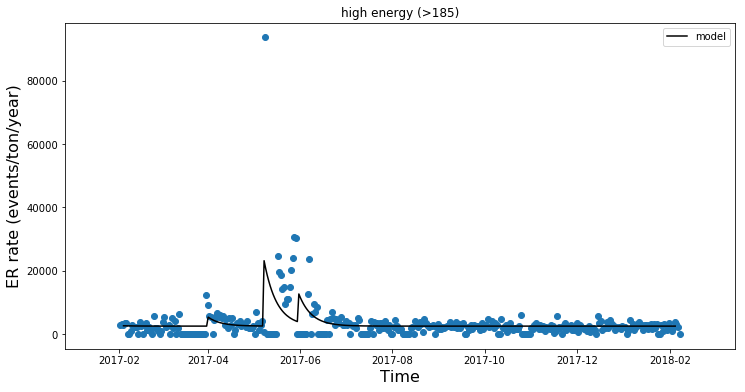

In [80]:
fig  = plt.figure(figsize=(12,6))
plt.title("high energy (>185)")
plt.xlabel('Time', fontsize=16)
plt.ylabel('ER rate (events/ton/year)', fontsize=16)
plt.scatter(datetime_breaks, rate_event_u)

plt.plot(dates, signal, label = 'model', color='black')

plt.legend()
plt.show()

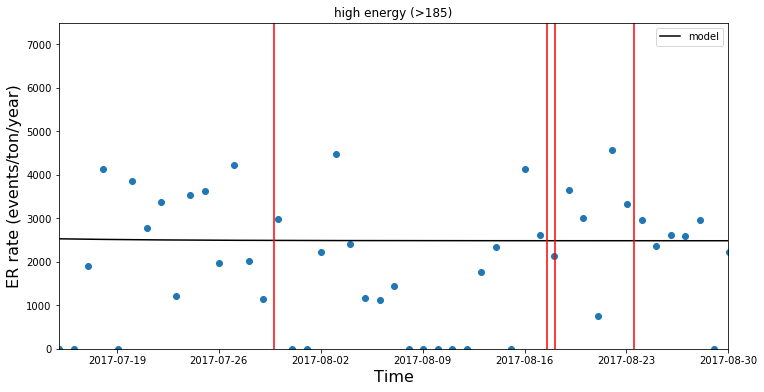

In [81]:
fig  = plt.figure(figsize=(12,6))
plt.title("high energy (>185)")
plt.xlabel('Time', fontsize=16)
plt.ylabel('ER rate (events/ton/year)', fontsize=16)
plt.scatter(datetime_breaks, rate_event_u)

plt.plot(dates, signal, label = 'model', color='black')

plt.ylim(0, 7500)
plt.xlim(datetime(2017, 7, 15), datetime(2017, 8, 30))

plt.axvline(GW_8_23_datetime, color='red')
plt.axvline(GW_8_18_datetime, color='red')
plt.axvline(GW_8_17_datetime, color='red')
plt.axvline(GW_7_29_datetime, color='red')

plt.legend()
plt.show()

In [198]:
#Expectation value for sideband time region

Data['Expected ER events (high) (/year)'] = ''
Data['systematic uncertainty (high) (/year)'] = ''

for j in range(0,4):
    for i in (range(0, np.shape(dates)[0])):
        if (Data['Event_date'][j].year == dates[i].year and Data['Event_date'][j].month == dates[i].month and Data['Event_date'][j].day == dates[i].day):
            Data['Expected ER events (high) (/year)'][j] = signal[i]
            Data['systematic uncertainty (high) (/year)'][j] = uncertainty[i]

Data['Expected bkgd ER events (high)'] = Data['Expected ER events (high) (/year)']*Data['livetime']/(365*60*60*24)
Data['systematic uncertainty (high)'] = Data['systematic uncertainty (high) (/year)']*1000/(365*60*60*24)

/cvmfs/xenon.opensciencegrid.org/releases/anaconda/2.4/envs/lower/lib/python3.4/site-packages/ipykernel/__main__.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
/cvmfs/xenon.opensciencegrid.org/releases/anaconda/2.4/envs/lower/lib/python3.4/site-packages/ipykernel/__main__.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy


# Sideband time regions

In [117]:
#ER_a is not in time of target GWs

ER_b_l = df_ER_b[(df_ER_b['energy']<=30)]
ER_b_p1 = df_ER_b[(df_ER_b['energy']<50) & (df_ER_b['energy']>30)]
ER_b_m = df_ER_b[(df_ER_b['energy']<=142) & (df_ER_b['energy']>=50)]
ER_b_p2 = df_ER_b[(df_ER_b['energy']>142) & (df_ER_b['energy']<185)]
ER_b_h = df_ER_b[(df_ER_b['energy']>=185)]

Data['n_ER'] = 0
Data['n_ER_l'] = 0
Data['n_ER_p1'] = 0
Data['n_ER_m'] = 0
Data['n_ER_p2'] = 0
Data['n_ER_h'] = 0

for j in range(0, np.shape(Data['Event_time'])[0]):
    for i in range(0, np.shape(df_ER_b['event_time'])[0]):
        id = df_ER_b.index[i]
        delay = Data['Event_time'][j] - df_ER_b['event_time'][id]*1e-9 
        if delay > 500 and delay<10500:
            Data['n_ER'][j] = Data['n_ER'][j] + 1
            
    for i in range(0, np.shape(ER_b_l['event_time'])[0]):
        id = ER_b_l.index[i]
        delay = Data['Event_time'][j] - ER_b_l['event_time'][id]*1e-9 
        if delay > 500 and delay<10500:
            Data['n_ER_l'][j] = Data['n_ER_l'][j] + 1

    for i in range(0, np.shape(ER_b_p1['event_time'])[0]):
        id = ER_b_p1.index[i]
        delay = Data['Event_time'][j] - ER_b_p1['event_time'][id]*1e-9 
        if delay > 500 and delay<10500:
            Data['n_ER_p1'][j] = Data['n_ER_p1'][j] + 1
            
    for i in range(0, np.shape(ER_b_m['event_time'])[0]):
        id = ER_b_m.index[i]
        delay = Data['Event_time'][j] - ER_b_m['event_time'][id]*1e-9 
        if delay > 500 and delay<10500:
            Data['n_ER_m'][j] = Data['n_ER_m'][j] + 1
            
    for i in range(0, np.shape(ER_b_p2['event_time'])[0]):
        id = ER_b_p2.index[i]
        delay = Data['Event_time'][j] - ER_b_p2['event_time'][id]*1e-9 
        if delay > 500 and delay<10500:
            Data['n_ER_p2'][j] = Data['n_ER_p2'][j] + 1
            
    for i in range(0, np.shape(ER_b_h['event_time'])[0]):
        id = ER_b_h.index[i]
        delay = Data['Event_time'][j] - ER_b_h['event_time'][id]*1e-9 
        if delay > 500 and delay<10500:
            Data['n_ER_h'][j] = Data['n_ER_h'][j] + 1
            
Data

/cvmfs/xenon.opensciencegrid.org/releases/anaconda/2.4/envs/lower/lib/python3.4/site-packages/ipykernel/__main__.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
/cvmfs/xenon.opensciencegrid.org/releases/anaconda/2.4/envs/lower/lib/python3.4/site-packages/ipykernel/__main__.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
/cvmfs/xenon.opensciencegrid.org/releases/anaconda/2.4/envs/lower/lib/python3.4/site-packages/ipykernel/__main__.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-cop

,Event,Event_date,Event_time,n_ER,start_time,end_time,missing_time,livetime,Expected ER events (/year),Expected bkgd ER events,...,Expected bkgd ER events (medium),Expected ER events (peak2) (/year),Expected bkgd ER events (peak2),Expected ER events (high) (/year),Expected bkgd ER events (high),n_ER_l,n_ER_p1,n_ER_m,n_ER_p2,n_ER_h
0,GW170729,2017-07-29 18:56:29+00:00,1.501355e+09,12,"[1501352317.0, 1501348706.0, 1501345098.0]","[1501352310.0, 1501348699.0, 1501345084.0]",28,9972,41124.1,13.0039,...,2.46429,23067.4,7.29416,2492.67,0.788207,0,1,2,9,0
1,GW170817,2017-08-17 12:41:04+00:00,1.502974e+09,9,"[1502971682.0, 1502968071.0, 1502964462.0]","[1502971675.0, 1502968064.0, 1502964455.0]",21,9979,27714.9,8.7699,...,2.45287,10264.9,3.24814,2485.38,0.786453,1,0,2,3,3
2,GW170818,2017-08-18 02:25:09+00:00,1.503023e+09,7,"[1503022261.0, 1503018651.0, 1503015039.0]","[1503022254.0, 1503018643.0, 1503015032.0]",22,9978,27332.5,8.64802,...,2.45283,9908.72,3.13512,2485.28,0.786344,0,2,1,4,0
3,GW170823,2017-08-23 13:13:58+00:00,1.503494e+09,6,"[1503492385.0, 1503488774.0, 1503485164.0]","[1503492378.0, 1503488767.0, 1503485157.0]",21,9979,25701.7,8.13284,...,2.45314,8409.95,2.66118,2484.96,0.78632,0,0,3,3,0


# Predictions for 1000 seconds time window

In [199]:
Data['Expected bkgd ER events (/1000s)'] = Data['Expected ER events (/year)']*1000/(365*60*60*24)
Data['Expected bkgd ER events (low) (/1000s)'] = Data['Expected ER events (low) (/year)']*1000/(365*60*60*24)
Data['Expected bkgd ER events (peak1) (/1000s)'] = Data['Expected ER events (peak1) (/year)']*1000/(365*60*60*24)
Data['Expected bkgd ER events (medium) (/1000s)'] = Data['Expected ER events (medium) (/year)']*1000/(365*60*60*24)
Data['Expected bkgd ER events (peak2) (/1000s)'] = Data['Expected ER events (peak2) (/year)']*1000/(365*60*60*24)
Data['Expected bkgd ER events (high) (/1000s)'] = Data['Expected ER events (high) (/year)']*1000/(365*60*60*24)

#Poisson fluctuation
Data['statistical uncertainty (high)'] = Data['Expected bkgd ER events (high) (/1000s)'] ** 0.5
Data['statistical uncertainty (peak2)'] = Data['Expected bkgd ER events (peak2) (/1000s)'] ** 0.5
Data['statistical uncertainty (medium)'] = Data['Expected bkgd ER events (medium) (/1000s)'] ** 0.5
Data['statistical uncertainty (peak1)'] = Data['Expected bkgd ER events (peak1) (/1000s)'] ** 0.5
Data['statistical uncertainty (low)'] = Data['Expected bkgd ER events (low) (/1000s)'] ** 0.5

Data['P_no_obs'] = ''
Data['P_no_obs_high'] = ''
Data['P_no_obs_low'] = ''
Data['P_no_obs_medium'] = ''
Data['P_no_obs_peak1'] = ''
Data['P_no_obs_peak2'] = ''

for i in range(0,4):
    Data['P_no_obs'][i] = poisson.cdf(0, Data['Expected bkgd ER events (/1000s)'][i])
    Data['P_no_obs_high'][i] = poisson.cdf(0, Data['Expected bkgd ER events (high) (/1000s)'][i])
    Data['P_no_obs_low'][i] = poisson.cdf(0, Data['Expected bkgd ER events (low) (/1000s)'][i])
    Data['P_no_obs_medium'][i] = poisson.cdf(0, Data['Expected bkgd ER events (medium) (/1000s)'][i])
    Data['P_no_obs_peak1'][i] = poisson.cdf(0, Data['Expected bkgd ER events (peak1) (/1000s)'][i])
    Data['P_no_obs_peak2'][i] = poisson.cdf(0, Data['Expected bkgd ER events (peak2) (/1000s)'][i])
    


/cvmfs/xenon.opensciencegrid.org/releases/anaconda/2.4/envs/lower/lib/python3.4/site-packages/ipykernel/__main__.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
/cvmfs/xenon.opensciencegrid.org/releases/anaconda/2.4/envs/lower/lib/python3.4/site-packages/ipykernel/__main__.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
/cvmfs/xenon.opensciencegrid.org/releases/anaconda/2.4/envs/lower/lib/python3.4/site-packages/ipykernel/__main__.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-cop

In [180]:
#90% confidence level
#20 independent bins

alpha = 1-(1-0.003)**(1/20) #Sidak Correction

Data['upper limit stat (low)'] = ''
Data['upper limit stat (peak1)'] = ''
Data['upper limit stat (medium)'] = ''
Data['upper limit stat (peak2)'] = ''
Data['upper limit stat (high)'] = ''

for i in range(0, 4):
    Data['upper limit stat (low)'][i] = poisson(mu=Data['Expected bkgd ER events (low) (/1000s)'][i]).ppf(1-alpha)
    Data['upper limit stat (peak1)'][i] = poisson(mu=Data['Expected bkgd ER events (peak1) (/1000s)'][i]).ppf(1-alpha)
    Data['upper limit stat (medium)'][i] = poisson(mu=Data['Expected bkgd ER events (medium) (/1000s)'][i]).ppf(1-alpha)
    Data['upper limit stat (peak2)'][i] = poisson(mu=Data['Expected bkgd ER events (peak2) (/1000s)'][i]).ppf(1-alpha)
    Data['upper limit stat (high)'][i] = poisson(mu=Data['Expected bkgd ER events (high) (/1000s)'][i]).ppf(1-alpha)

/cvmfs/xenon.opensciencegrid.org/releases/anaconda/2.4/envs/lower/lib/python3.4/site-packages/ipykernel/__main__.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
/cvmfs/xenon.opensciencegrid.org/releases/anaconda/2.4/envs/lower/lib/python3.4/site-packages/ipykernel/__main__.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
/cvmfs/xenon.opensciencegrid.org/releases/anaconda/2.4/envs/lower/lib/python3.4/site-packages/ipykernel/__main__.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-cop